In [81]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


## Logistic Regression Parameters
**1) penalty**
> penalty: Literal['l1','l2','elasticnnet'] |  none = 'l1' 
* model = LogisticRegression(penalty='l1')
* model = LogisticRegression(penalty='l2')
* model = LogisticRegression(penalty='elasticnet')

**2) solver**
> solver: Literal['lbfs','liblinear','newton-cg','newton-cholesky','sag,'saga'] = 'lbfgs'
* it is an optimization engine helps the gradient descent to optimize the weights
* sag and saga we use when we have more features ...that scenario we get during sentence based classification

|solver |penalty | moltinomial multiclass|
|-------|--------|-----------------------|
|'lbfgs' | l2',None|yes|
|'liblinear'|'l2','l2'| no|
|'newton-cg'|l2',None |yes|
|'newton-cholesky'|l2',None| yes|
|'sag'|l2',None|yes|
|'saga'|'elasticnet,l1,l2|yes|

**3) max_iter**
>max_iter: int, default=100 Maximum number of iterations taken for the solvers to converge.

**4) class_weight**
>class_weight: dict or 'balanced', default=None Weights associated with classes in the form {class_label: weight}. If not given, all classes are supposed to have weight one.
* we use this when we have imbalanced dataset

**5) tol**
>tol: float, default=1e-4 Tolerance for stopping criteria.

**6) C**
>C: float, default=1.0 Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization.


In [82]:
df = pd.read_csv(r"C:\Users\Test\Desktop\PySpiders\Machine_Learning\Datasets\loan_approval_dataset.csv")

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                1000 non-null   int64
 1   Salary             1000 non-null   int64
 2   Credit_Score       1000 non-null   int64
 3   Loan_Amount        1000 non-null   int64
 4   Loan_Term          1000 non-null   str  
 5   Employment_Status  1000 non-null   str  
 6   Residence_Type     1000 non-null   str  
 7   Previous_Default   1000 non-null   str  
 8   Loan_Approved      1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [84]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [85]:
X = df.drop(columns='Loan_Approved')
y = df['Loan_Approved']

In [86]:
X.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [87]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,train_size = 0.8, random_state=42)

In [88]:
num_col = X.select_dtypes(include='number').columns
obj_col = X.select_dtypes(include='str').columns

<Axes: >

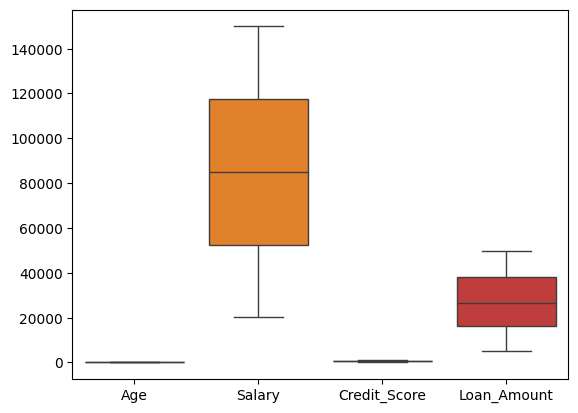

In [89]:
sns.boxplot(X[num_col])

In [90]:
X[obj_col].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

## Preprocessing techniques ##
**Scaling**
>why scaling?
* we are using scaling because the numerical columns are in different range, if we train the model as it is it will give more importance to the higher range columns so we can us scaling techniques to give equal importance to all the columns
* since we have no outliers in the numberical columns we can use MinMaxScaler

**Encoding**
>why encoding?
* Algorithms can only understand numbers not string becuse they internally uses statistical formulas
* so we need to convert string columns into numerical columns using encoding techniques

>Which scaling and encoding we can use here?
* scaling - MinMaxScaler
* Encoding - OneHotEncoder


In [91]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaling = MinMaxScaler()
model = LogisticRegression()

In [92]:
# update xtrain
xtrain[num_col] = scaling.fit_transform(xtrain[num_col])

encoded_values = encoder.fit_transform(xtrain[obj_col])
encoded_columns = encoder.get_feature_names_out()
xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_col,inplace=True)

In [93]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [94]:
#update xtest
xtest[num_col] = scaling.transform(xtest[num_col])

xtest_encoded_values = encoder.transform(xtest[obj_col])
xtest[encoded_columns] = xtest_encoded_values
xtest.drop(columns=obj_col,inplace=True)

In [95]:
xtest

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [96]:
model.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul